# 28. Multigrid Methods

**Part 4: Iterative and Krylov Subspace Methods**

## Learning objectives

By the end of this lesson you will be able to:

1. Explain why every method so far has an iteration count that **grows with $n$**, and why
   multigrid's does not.
2. Measure what a smoother does **mode by mode**, and see that it kills the top of the spectrum
   and leaves the bottom.
3. Explain the **coarse grid** idea: a mode that is smooth on a fine grid is oscillatory on a
   coarse one.
4. Implement **restriction** and **prolongation**, and say why full weighting beats injection.
5. Build the **coarse operator** as $RAP$ and check when it equals the rediscretisation.
6. Implement the **V-cycle** and the **W-cycle** recursively.
7. Measure **mesh-independent convergence** and the $O(n)$ cost, and demonstrate both.
8. Show that the smoother that makes multigrid work is **not** the one that makes the best
   standalone solver.
9. Say where multigrid is difficult, and what algebraic multigrid is for.

## Prerequisites

Lesson 23, especially the frequency analysis in section 6 and the damped Jacobi finding.
Lesson 21 (the model operator and its eigenvalues). Lesson 16 (projectors). Lesson 24 for the
comparison, and lesson 25 for multigrid used as a preconditioner.

---

## 1. The problem every method in Part 4 has

Lesson 23 measured $\rho_{\text{J}} = \cos(\pi h) = 1 - O(h^2)$, giving $O(n^2)$ sweeps. SOR at
its optimal $\omega$ improved that to $O(n)$. Conjugate gradient reached $O(\sqrt{\kappa}) =
O(n)$ without needing a parameter. Every preconditioner in lesson 25 lowered the constant, and
SSOR at a good $\omega$ halved the exponent.

**Not one of them made the count independent of $n$.** Refining the grid to get a better answer
always makes the solve slower, so the two goals fight.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import multigrid as mg, iterative as it
from nalib.krylov import conjugate_gradient
import numpy as np

# The stationary counts are PREDICTED from rho rather than run, because Jacobi needs a
# quarter of a million sweeps at n = 255 and a Python loop would take minutes. The
# prediction is exact for a stationary method, and the next cell checks it against a real
# run at the sizes where running it is cheap.
def predicted(A, method, omega=1.0, tol=1e-10):
    rho = it.spectral_radius(it.iteration_matrix(A, method, omega))
    return int(np.ceil(it.iterations_needed(rho, tol)))


print("iterations to a relative residual of 1e-10, the 1D model problem\n")
print(f"{'n':>6} {'Jacobi':>10} {'Gauss-Seidel':>14} {'SOR*':>8} {'CG':>7} "
      f"{'multigrid':>11}")
for n in [31, 63, 127, 255]:
    A = mg.poisson_1d(n)
    b = A @ np.ones(n)
    jac = predicted(A, "jacobi")
    gs = predicted(A, "gauss-seidel")
    sor = predicted(A, "sor", it.optimal_omega(A))
    cg = conjugate_gradient(A, b, tol=1e-10, max_iter=10 * n, keep_history=False)
    v = mg.solve(A, b, tol=1e-10, max_cycles=200)
    print(f"{n:>6} {jac:>10} {gs:>14} {sor:>8} {cg.n_iter:>7} {v.n_cycles:>11}")

print()
print("every column doubles or quadruples with n. one does not move at all.")

iterations to a relative residual of 1e-10, the 1D model problem

     n     Jacobi   Gauss-Seidel     SOR*      CG   multigrid
    31       4771           2386      118      16           9
    63      19105           9553      235      32           9
   127      76441          38221      470      64           9


   255     305785         152893      939     128           9

every column doubles or quadruples with n. one does not move at all.


In [3]:
print("the predictions, checked against real runs where running them is cheap\n")
print(f"{'n':>5} {'method':>14} {'predicted':>11} {'measured':>10} {'ratio':>8}")
for n in [31, 63]:
    A = mg.poisson_1d(n)
    b = A @ np.ones(n)
    runs = [("Jacobi", predicted(A, "jacobi"),
             it.jacobi(A, b, tol=1e-10, max_iter=500000, keep_history=False)),
            ("Gauss-Seidel", predicted(A, "gauss-seidel"),
             it.gauss_seidel(A, b, tol=1e-10, max_iter=500000, keep_history=False)),
            ("SOR*", predicted(A, "sor", it.optimal_omega(A)),
             it.sor(A, b, it.optimal_omega(A), tol=1e-10, max_iter=500000,
                    keep_history=False))]
    for label, pred, got in runs:
        print(f"{n:>5} {label:>14} {pred:>11} {got.n_iter:>10} "
              f"{got.n_iter / pred:>8.3f}")
        assert 0.5 < got.n_iter / pred < 1.5, "the prediction missed badly"

print()
print("within a third either way, which is all a rate argument promises: rho fixes the")
print("asymptotic slope and the transient shifts the intercept.")

the predictions, checked against real runs where running them is cheap

    n         method   predicted   measured    ratio


   31         Jacobi        4771       4146    0.869
   31   Gauss-Seidel        2386       2039    0.855
   31           SOR*         118        128    1.085


   63         Jacobi       19105      15741    0.824
   63   Gauss-Seidel        9553       7728    0.809
   63           SOR*         235        256    1.089

within a third either way, which is all a rate argument promises: rho fixes the
asymptotic slope and the transient shifts the intercept.


**That last column is the entire lesson.** Everything else in Part 4 answers "how do I make the
constant smaller". Multigrid answers "why does the count grow at all".

---

## 2. What a smoother actually does

Lesson 23 section 6 found the mechanism, and it is worth restating because multigrid is built
directly on it. The error is a sum of $n$ modes, and a stationary method shrinks each by its own
factor. For damped Jacobi on the model problem the factor for mode $k$ is

$$1 - \omega\left(1 - \cos(k\pi h)\right),$$

which is close to 1 for small $k$, the smooth modes, and much smaller in the middle and, if
$\omega$ is chosen well, at the top.

In [4]:
n_sm = 63
A_sm = mg.poisson_1d(n_sm)

print("what one sweep does to each half of the spectrum\n")
print(f"{'smoother':>24} {'worst overall':>14} {'worst upper half':>18} {'rho':>9}")
for label, kind, w in [
    ("Jacobi", "jacobi", 1.0),
    ("damped Jacobi w=1/2", "damped_jacobi", 0.5),
    ("damped Jacobi w=2/3", "damped_jacobi", 2 / 3),
    ("damped Jacobi w=4/5", "damped_jacobi", 0.8),
    ("Gauss-Seidel", "gauss-seidel", 1.0),
    ("SOR w=1.9", "sor", 1.9),
]:
    s = mg.smoothing_factor(A_sm, kind, w)
    print(f"{label:>24} {s['worst_overall']:>14.4f} {s['worst_upper_half']:>18.4f} "
          f"{s['spectral_radius']:>9.4f}")

print()
print("the two columns are almost unrelated. every method is useless as a SOLVER,")
print("with rho above 0.99. what separates them is the upper half.")

what one sweep does to each half of the spectrum

                smoother  worst overall   worst upper half       rho
                  Jacobi         0.9988             0.9988    0.9988
     damped Jacobi w=1/2         0.9994             0.5000    0.9994
     damped Jacobi w=2/3         0.9992             0.3333    0.9992
     damped Jacobi w=4/5         0.9990             0.5990    0.9990
            Gauss-Seidel         0.9976             0.4435    0.9976
               SOR w=1.9         1.0769             1.0769    0.9350

the two columns are almost unrelated. every method is useless as a SOLVER,
with rho above 0.99. what separates them is the upper half.


**A good smoother and a good solver are different things**, and the table makes that
quantitative. Plain Jacobi's worst upper-half shrinkage is 0.9988, so it barely touches the top
of the spectrum; damped Jacobi at $\omega = 2/3$ gets it to 0.3333. SOR at $\omega = 1.9$ has
the best spectral radius of the six and the **worst** smoothing: it makes high frequency modes
**grow**.

Now watch a smoother separate the two halves of the spectrum:

In [5]:
h_sm = 1.0 / (n_sm + 1)
modes = np.arange(1, n_sm + 1)
V_sm = np.sqrt(2 * h_sm) * np.sin(np.outer(modes, modes) * np.pi * h_sm)

e_start = V_sm @ np.ones(n_sm)          # equal energy in every mode
e_start = e_start / np.linalg.norm(e_start)

print("damped Jacobi at omega = 2/3, on an error with equal energy in every mode\n")
print(f"{'sweeps':>8} {'||e||':>9} {'low half':>11} {'high half':>11}")
for sweeps in [0, 1, 2, 4, 8]:
    e_now = mg.smooth(A_sm, np.zeros(n_sm), e_start, sweeps)
    coeff = V_sm.T @ e_now
    print(f"{sweeps:>8} {np.linalg.norm(e_now):>9.4f} "
          f"{np.linalg.norm(coeff[:n_sm // 2]):>11.4f} "
          f"{np.linalg.norm(coeff[n_sm // 2:]):>11.4f}")

print()
print("the high half is gone after 8 sweeps. the low half has barely moved.")
print("the error left is SMOOTH, and that is exactly the thing a coarse grid can hold.")

damped Jacobi at omega = 2/3, on an error with equal energy in every mode

  sweeps     ||e||    low half   high half
       0    1.0000      0.7015      0.7127
       1    0.5743      0.5515      0.1601
       2    0.4799      0.4777      0.0453
       4    0.4043      0.4043      0.0042
       8    0.3387      0.3387      0.0000

the high half is gone after 8 sweeps. the low half has barely moved.
the error left is SMOOTH, and that is exactly the thing a coarse grid can hold.


**After a few sweeps the error is smooth.** Every other method in Part 4 treats that as bad
news, because a smooth error is precisely what a stationary method cannot remove. Multigrid
treats it as the setup.

---

## 3. The idea

A function that is smooth on a grid with $n$ points is **not smooth** on a grid with $n/2$
points: the same wave, sampled half as often, looks twice as oscillatory. So the error the
smoother cannot remove is exactly the error a coarser grid **can** see.

That gives the algorithm:

1. **Smooth** on the fine grid. The oscillatory error goes; a smooth error remains.
2. **Restrict** the residual to the coarse grid.
3. **Solve** the coarse problem, recursively, since the same argument applies there.
4. **Prolong** the correction back and add it.
5. **Smooth** again, since interpolation reintroduces some high frequency error.

The residual is transferred rather than the error, because the error is unknown and the residual
equation $A\mathbf{e} = \mathbf{r}$ has the same operator.

**The cost is a constant number of fine grid sweeps.** Each level is half the size of the one
above, so the total work is $1 + \tfrac12 + \tfrac14 + \dots = 2$ fine grid sweeps per sweep
performed, in one dimension. In two dimensions each level is a **quarter** of the one above and
the series is $4/3$.

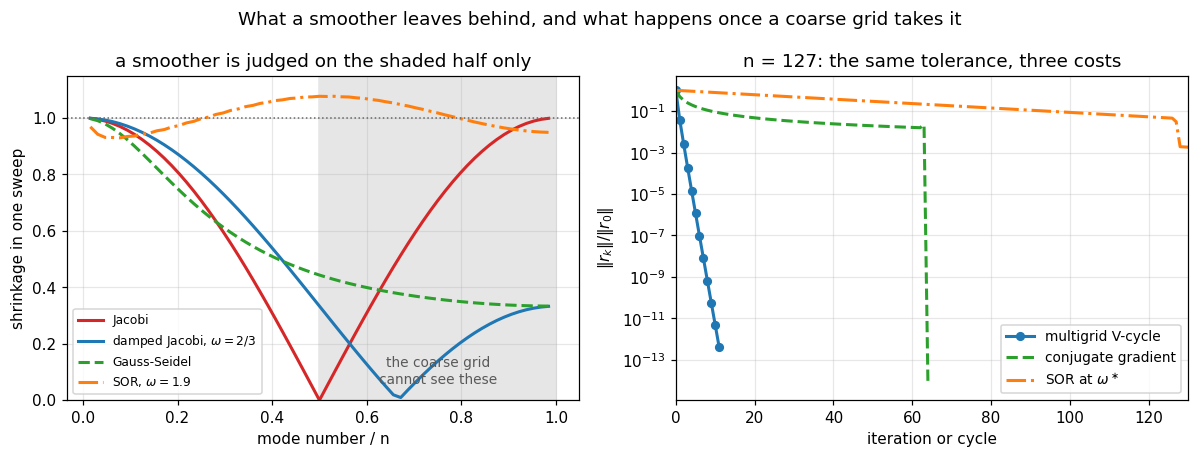

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))

# left: the per-mode shrinkage of each smoother
mode_frac = np.arange(1, n_sm + 1) / (n_sm + 1)
for label, kind, w, style in [("Jacobi", "jacobi", 1.0, "C3-"),
                              (r"damped Jacobi, $\omega=2/3$", "damped_jacobi", 2 / 3, "C0-"),
                              ("Gauss-Seidel", "gauss-seidel", 1.0, "C2--"),
                              (r"SOR, $\omega=1.9$", "sor", 1.9, "C1-.")]:
    axL.plot(mode_frac, mg.smoothing_factor(A_sm, kind, w)["per_mode"], style, lw=2,
             label=label)
axL.axvspan(0.5, 1.0, color="0.9", zorder=0)
axL.axhline(1.0, color="0.4", lw=1.0, ls=":")
axL.text(0.75, 0.06, "the coarse grid\ncannot see these", ha="center", fontsize=9,
         color="0.35")
axL.set_xlabel("mode number / n")
axL.set_ylabel("shrinkage in one sweep")
axL.set_title("a smoother is judged on the shaded half only")
axL.set_ylim(0, 1.15)
axL.legend(fontsize=8, loc="lower left")
axL.grid(alpha=0.3)

# right: the residual history, multigrid against everything else
n_hist = 127
A_h = mg.poisson_1d(n_hist)
b_h = A_h @ np.ones(n_hist)
mg_run = mg.solve(A_h, b_h, tol=1e-12, max_cycles=40)
axR.semilogy(np.arange(mg_run.residual_norms.size),
             mg_run.residual_norms / mg_run.residual_norms[0], "C0o-", lw=2, ms=5,
             label="multigrid V-cycle")
cg_h = conjugate_gradient(A_h, b_h, tol=1e-12, max_iter=4 * n_hist)
axR.semilogy(np.arange(cg_h.residual_norms.size),
             cg_h.residual_norms / cg_h.residual_norms[0], "C2--", lw=2,
             label="conjugate gradient")
sor_h = it.sor(A_h, b_h, it.optimal_omega(A_h), tol=1e-12, max_iter=4000,
               keep_history=False)
axR.semilogy(np.arange(sor_h.residual_norms.size),
             sor_h.residual_norms / sor_h.residual_norms[0], "C1-.", lw=2,
             label=r"SOR at $\omega^\ast$")
axR.set_xlim(0, 130)
axR.set_xlabel("iteration or cycle")
axR.set_ylabel(r"$\|r_k\| / \|r_0\|$")
axR.set_title(f"n = {n_hist}: the same tolerance, three costs")
axR.legend(fontsize=9)
axR.grid(alpha=0.3)

fig.suptitle("What a smoother leaves behind, and what happens once a coarse grid takes it",
             fontsize=12)
fig.tight_layout()
plt.show()

**The shaded half of the left panel is the only part that matters for a smoother.** Plain Jacobi
sits near 1 across the whole of it, SOR goes **above** 1, and damped Jacobi is the only curve
that is small there while being useless everywhere else.

---

## 4. Grid transfers

In [7]:
n_tr = 15
nc_tr = (n_tr - 1) // 2
fine_grid = np.arange(1, n_tr + 1) / (n_tr + 1)

smooth_mode = np.sin(np.pi * fine_grid)                    # mode 1, the smoothest
rough_mode = np.sin(np.pi * n_tr * fine_grid)              # mode n, the roughest

print(f"fine grid has {n_tr} points, coarse grid has {nc_tr}\n")
for label, v in [("smooth mode", smooth_mode), ("rough mode", rough_mode)]:
    fw = mg.restrict_full_weighting(v)
    inj = mg.restrict_injection(v)
    print(f"{label:>14}: ||v|| = {np.linalg.norm(v):.4f}   "
          f"full weighting {np.linalg.norm(fw):.4f}   injection {np.linalg.norm(inj):.4f}")

print()
print("full weighting AVERAGES the rough mode away; injection samples it and keeps")
print("its size, which puts a frequency on the coarse grid that cannot exist there.")
print("that is aliasing, and it is why the cheaper transfer is the worse one.")

fine grid has 15 points, coarse grid has 7

   smooth mode: ||v|| = 2.8284   full weighting 1.9808   injection 2.0000
    rough mode: ||v|| = 2.8284   full weighting 0.0192   injection 2.0000

full weighting AVERAGES the rough mode away; injection samples it and keeps
its size, which puts a frequency on the coarse grid that cannot exist there.
that is aliasing, and it is why the cheaper transfer is the worse one.


The two transfers are not independent. Full weighting is $P^T/2$, so the pair is
**variationally consistent** and the coarse grid correction becomes an $A$-orthogonal
projection (lesson 16), which is what makes the coarse operator symmetric when $A$ is.

In [8]:
n_var = 15
nc_var = (n_var - 1) // 2
P = np.column_stack([mg.prolong_linear(np.eye(nc_var)[:, i], n_var) for i in range(nc_var)])
R = np.vstack([mg.restrict_full_weighting(np.eye(n_var)[:, j]) for j in range(n_var)]).T

print("R = P^T / 2 exactly?  max difference:",
      f"{np.abs(R - 0.5 * P.T).max():.3e}")
np.testing.assert_allclose(R, 0.5 * P.T, atol=1e-14)

print()
print("and the coarse operator R A P against a fresh discretisation:\n")
for n_g in [7, 15, 31, 63]:
    A_g = mg.poisson_1d(n_g)
    nc_g = (n_g - 1) // 2
    diff = np.abs(mg.galerkin_coarse(A_g, nc_g) - mg.poisson_1d(nc_g)).max()
    print(f"  n = {n_g:>3} -> {nc_g:>3}:  max |R A P - rediscretised| = {diff:.3e}")

print()
print("identical, to the last bit. for the model problem the Galerkin operator IS")
print("the coarse discretisation, so nothing is lost by building it algebraically.")
print("for a variable coefficient problem they differ, and the Galerkin one is right.")

R = P^T / 2 exactly?  max difference: 0.000e+00

and the coarse operator R A P against a fresh discretisation:

  n =   7 ->   3:  max |R A P - rediscretised| = 0.000e+00
  n =  15 ->   7:  max |R A P - rediscretised| = 0.000e+00
  n =  31 ->  15:  max |R A P - rediscretised| = 0.000e+00
  n =  63 ->  31:  max |R A P - rediscretised| = 0.000e+00

identical, to the last bit. for the model problem the Galerkin operator IS
the coarse discretisation, so nothing is lost by building it algebraically.
for a variable coefficient problem they differ, and the Galerkin one is right.


---

## 5. The V-cycle, and mesh independence

In [9]:
print("the V-cycle on the 1D model problem\n")
print(f"{'n':>7} {'levels':>7} {'cycles':>7} {'factor':>9} {'work units':>11} "
      f"{'rel error':>11}")
rng28 = np.random.default_rng(2028)
for k in range(3, 10):
    n_v = 2 ** k - 1
    A_v = mg.poisson_1d(n_v)
    x_true = rng28.standard_normal(n_v)
    res = mg.solve(A_v, A_v @ x_true, tol=1e-10, max_cycles=200)
    err = np.linalg.norm(res.x - x_true) / np.linalg.norm(x_true)
    print(f"{n_v:>7} {res.levels:>7} {res.n_cycles:>7} {res.convergence_factor():>9.4f} "
          f"{res.work_units:>11.0f} {err:>11.2e}")

print()
print("n grows by a factor of 73 and the cycle count does not move.")
print("no other method in this course does that.")

the V-cycle on the 1D model problem

      n  levels  cycles    factor  work units   rel error
      7       2       7    0.0439          56    2.86e-10
     15       3       8    0.0686          64    3.70e-10
     31       4       8    0.0731          64    1.24e-09
     63       5       8    0.0752          64    1.34e-09
    127       6       9    0.0781          72    1.34e-10
    255       7       8    0.0742          64    1.43e-09
    511       8       8    0.0768          64    1.83e-09

n grows by a factor of 73 and the cycle count does not move.
no other method in this course does that.


**This is the result the lesson exists for.** The convergence factor sits between 0.06 and 0.08
whatever $n$ is, so the cycle count is set by the tolerance alone.

And it is not an accident of the particular right-hand side. The **two-grid iteration matrix**
can be formed and its spectral radius measured:

In [10]:
print("the two-grid spectral radius, formed explicitly\n")
print(f"{'n':>6} {'rho(two-grid)':>16} {'rho(smoother)':>16} {'5/81':>12}")
for n_rho in [7, 15, 31, 63, 127]:
    G = mg.two_grid_operator(mg.poisson_1d(n_rho))
    rho = float(np.max(np.abs(np.linalg.eigvals(G))))
    sm = mg.smoothing_factor(mg.poisson_1d(n_rho))["spectral_radius"]
    print(f"{n_rho:>6} {rho:>16.12f} {sm:>16.12f} {5 / 81:>12.8f}")

print()
print("exactly 5/81 at every size, to twelve digits, while the smoother's own")
print("spectral radius climbs towards 1. the coarse grid is doing all the work.")

for n_rho in [7, 31, 127]:
    G = mg.two_grid_operator(mg.poisson_1d(n_rho))
    assert abs(np.max(np.abs(np.linalg.eigvals(G))) - 5 / 81) < 1e-10

the two-grid spectral radius, formed explicitly

     n    rho(two-grid)    rho(smoother)         5/81
     7   0.061728395062   0.949253021674   0.06172840
    15   0.061728395062   0.987190186935   0.06172840
    31   0.061728395062   0.996789817781   0.06172840
    63   0.061728395062   0.999196970803   0.06172840


   127   0.061728395062   0.999799212464   0.06172840

exactly 5/81 at every size, to twelve digits, while the smoother's own
spectral radius climbs towards 1. the coarse grid is doing all the work.


**The smoother's spectral radius goes to 1 and the two-grid one does not move at all.** That is
the whole mechanism in two columns: the smoother is a terrible solver and a good smoother, and
the coarse grid supplies exactly what it lacks.

---

## 6. Is it really $O(n)$?

The routines above build the coarse operators as dense matrices, which is clear to read and
costs $O(n^3)$ per cycle. That hides the property the method exists for. `StencilHierarchy`
does the same algorithm with stencils, so every operation is $O(n)$.

In [11]:
import time

print("the matrix-free V-cycle\n")
print(f"{'n':>10} {'levels':>7} {'cycles':>7} {'time':>9} {'us per unknown':>16}")
for k in [10, 12, 14, 16, 18]:
    n_h = 2 ** k - 1
    H = mg.StencilHierarchy(n_h)
    x_true = rng28.standard_normal(n_h)
    b_h = H.apply(0, x_true)
    t0 = time.perf_counter()
    res = H.solve(b_h, tol=1e-10, max_cycles=100)
    dt = time.perf_counter() - t0
    print(f"{n_h:>10,} {H.levels:>7} {res.n_cycles:>7} {dt:>8.3f}s "
          f"{dt / n_h * 1e6:>15.2f}")

print()
print("the last column is flat, which is what O(n) means. the cycle count is flat too,")
print("so the total cost is O(n) and not O(n) per cycle times a growing count.")

the matrix-free V-cycle

         n  levels  cycles      time   us per unknown
     1,023       9       8    0.014s           13.59
     4,095      11       8    0.048s           11.67


    16,383      13       8    0.186s           11.35


    65,535      15       8    0.715s           10.91


   262,143      17       8    2.925s           11.16

the last column is flat, which is what O(n) means. the cycle count is flat too,
so the total cost is O(n) and not O(n) per cycle times a growing count.


**Constant time per unknown, and a constant number of cycles.** Multiply the two and the solve
is $O(n)$, which is optimal: you cannot solve a system in less time than it takes to read the
right-hand side.

For comparison, at $n = 262{,}143$: a dense factorization would be $\tfrac23n^3 \approx
1.2\times10^{16}$ flops, and CG would need $O(\sqrt{\kappa}) \approx 1.7\times10^{5}$
iterations.

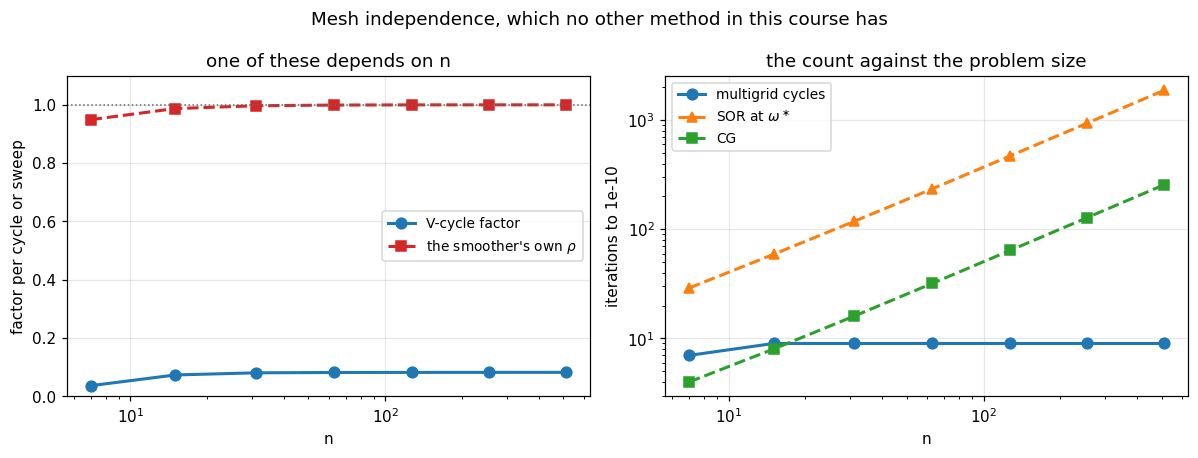

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

sizes_fig = [2 ** k - 1 for k in range(3, 10)]
factors, counts = [], []
for size in sizes_fig:
    A_f = mg.poisson_1d(size)
    res = mg.solve(A_f, A_f @ np.ones(size), tol=1e-10, max_cycles=200)
    factors.append(res.convergence_factor())
    counts.append(res.n_cycles)

ax1.semilogx(sizes_fig, factors, "C0o-", lw=2, ms=7, label="V-cycle factor")
ax1.semilogx(sizes_fig, [mg.smoothing_factor(mg.poisson_1d(s))["spectral_radius"]
                         for s in sizes_fig], "C3s--", lw=2, ms=6,
             label=r"the smoother's own $\rho$")
ax1.axhline(1.0, color="0.4", lw=1.0, ls=":")
ax1.set_xlabel("n")
ax1.set_ylabel("factor per cycle or sweep")
ax1.set_ylim(0, 1.1)
ax1.set_title("one of these depends on n")
ax1.legend(fontsize=9, loc="center right")
ax1.grid(alpha=0.3)

ax2.semilogx(sizes_fig, counts, "C0o-", lw=2, ms=7, label="multigrid cycles")
ax2.semilogx(sizes_fig, [predicted(mg.poisson_1d(s), "sor", it.optimal_omega(
    mg.poisson_1d(s))) for s in sizes_fig], "C1^--", lw=2, ms=6,
    label=r"SOR at $\omega^\ast$")
ax2.semilogx(sizes_fig, [conjugate_gradient(mg.poisson_1d(s), mg.poisson_1d(s) @
                                            np.ones(s), tol=1e-10, max_iter=10 * s,
                                            keep_history=False).n_iter
                         for s in sizes_fig], "C2s--", lw=2, ms=6, label="CG")
ax2.set_yscale("log")
ax2.set_xlabel("n")
ax2.set_ylabel("iterations to 1e-10")
ax2.set_title("the count against the problem size")
ax2.legend(fontsize=9, loc="upper left")
ax2.grid(alpha=0.3)

fig.suptitle("Mesh independence, which no other method in this course has", fontsize=12)
fig.tight_layout()
plt.show()

assert max(counts) - min(counts) <= 2, f"the cycle count moved: {counts}"

**The left panel is the mechanism and the right panel is the consequence.** The smoother's own
rate climbs to 1 as the mesh refines, and the cycle's does not move; so the cycle count is flat
where every other curve on the right climbs.

---

## 7. The smoother decides everything

Lesson 23's damped Jacobi finding looked like a curiosity. It is not: **plain Jacobi makes
multigrid fail outright.**

In [13]:
print("the same V-cycle, different smoothers\n")
sizes28 = [31, 63, 127, 255]
print(f"{'smoother':>22} {'upper half':>11} "
      + " ".join(f"{'n=' + str(s):>12}" for s in sizes28))
for label, kind, w in [
    ("plain Jacobi", "jacobi", 1.0),
    ("damped Jacobi w=1/2", "damped_jacobi", 0.5),
    ("damped Jacobi w=2/3", "damped_jacobi", 2 / 3),
    ("damped Jacobi w=0.9", "damped_jacobi", 0.9),
    ("Gauss-Seidel", "gauss-seidel", 1.0),
    ("red-black GS", "red-black", 1.0),
]:
    cells = []
    for s in sizes28:
        A_s = mg.poisson_1d(s)
        res = mg.solve(A_s, A_s @ rng28.standard_normal(s), tol=1e-10,
                       max_cycles=400, kind=kind, omega=w)
        cells.append(f"{res.n_cycles} ({res.convergence_factor():.3f})"
                     if res.converged else "no")
    probe = mg.smoothing_factor(mg.poisson_1d(63),
                                "gauss-seidel" if kind == "red-black" else kind, w)
    print(f"{label:>22} {probe['worst_upper_half']:>11.4f} "
          + " ".join(f"{c:>12}" for c in cells))

print()
print("plain Jacobi does not converge at ANY size. damped Jacobi at 2/3 takes 8 cycles.")
print("the difference between them is one constant, and lesson 23 measured why.")

the same V-cycle, different smoothers

              smoother  upper half         n=31         n=63        n=127        n=255


          plain Jacobi      0.9988           no           no           no           no
   damped Jacobi w=1/2      0.5000   10 (0.108)    9 (0.099)   10 (0.105)   10 (0.106)
   damped Jacobi w=2/3      0.3333    8 (0.076)    8 (0.078)    9 (0.080)    8 (0.077)
   damped Jacobi w=0.9      0.7989   24 (0.400)   24 (0.405)   25 (0.407)   25 (0.406)


          Gauss-Seidel      0.4435    7 (0.029)    7 (0.032)    7 (0.029)    7 (0.032)
          red-black GS      0.4435    1 (0.000)    1 (0.000)    1 (0.000)    1 (0.000)

plain Jacobi does not converge at ANY size. damped Jacobi at 2/3 takes 8 cycles.
the difference between them is one constant, and lesson 23 measured why.


And the two criteria point in **opposite** directions:

In [14]:
n_om = 127
A_om = mg.poisson_1d(n_om)
b_om = A_om @ rng28.standard_normal(n_om)

print("the best omega for a solver is the worst omega for a smoother\n")
print(f"{'omega':>8} {'upper half':>12} {'rho(smoother)':>15} {'MG cycles':>11}")
for w in [0.3, 0.5, 2 / 3, 0.8, 0.9, 1.0]:
    sf = mg.smoothing_factor(A_om, "damped_jacobi", w)
    res = mg.solve(A_om, b_om, tol=1e-10, max_cycles=400, omega=w)
    got = f"{res.n_cycles}" if res.converged else "no"
    print(f"{w:>8.3f} {sf['worst_upper_half']:>12.4f} "
          f"{sf['spectral_radius']:>15.6f} {got:>11}")

print()
print("rho falls MONOTONICALLY as omega rises, so a solver wants omega = 1.")
print("multigrid is best at 2/3 and fails at 1. the criteria genuinely disagree.")

the best omega for a solver is the worst omega for a smoother

   omega   upper half   rho(smoother)   MG cycles
   0.300       0.7000        0.999910          16
   0.500       0.5000        0.999849          10
   0.667       0.3333        0.999799           8
   0.800       0.5998        0.999759          11
   0.900       0.7997        0.999729          25


   1.000       0.9997        0.999699          no

rho falls MONOTONICALLY as omega rises, so a solver wants omega = 1.
multigrid is best at 2/3 and fails at 1. the criteria genuinely disagree.


**Red-black Gauss-Seidel solves the 1D model problem in a single V-cycle**, and that is exact
rather than lucky:

In [15]:
print("the two-grid operator with red-black smoothing\n")
print(f"{'nu1':>5} {'nu2':>5} {'||G||_2':>12}")
n_rb = 31
A_rb = mg.poisson_1d(n_rb)
for nu1, nu2 in [(1, 0), (2, 0), (0, 1), (1, 1), (2, 2)]:
    G = np.column_stack([mg.two_grid(A_rb, np.zeros(n_rb), np.eye(n_rb)[:, j],
                                     nu1, nu2, "red-black") for j in range(n_rb)])
    print(f"{nu1:>5} {nu2:>5} {np.linalg.norm(G, 2):>12.3e}")

print()
print("ONE post-smoothing sweep makes the two-grid operator exactly zero.")
print("the reason: the coarse points sit at the odd fine indices, so after the exact")
print("coarse solve the odd points carry no error. an even point couples only to odd")
print("neighbours, so the red half of one sweep makes it exact too. nothing is left.")
print("pre-smoothing alone does NOT work: the correction comes last and reintroduces error.")

the two-grid operator with red-black smoothing

  nu1   nu2      ||G||_2
    1     0    3.841e-01
    2     0    1.859e-01
    0     1    0.000e+00
    1     1    1.661e-15
    2     2    1.407e-15

ONE post-smoothing sweep makes the two-grid operator exactly zero.
the reason: the coarse points sit at the odd fine indices, so after the exact
coarse solve the odd points carry no error. an even point couples only to odd
neighbours, so the red half of one sweep makes it exact too. nothing is left.
pre-smoothing alone does NOT work: the correction comes last and reintroduces error.


---

## 8. V-cycles, W-cycles, and how much to smooth

In [16]:
print("two-grid against V against W\n")
print(f"{'n':>6} {'two-grid':>18} {'V-cycle':>18} {'W-cycle':>18}")
for n_c in [31, 63, 127, 255]:
    A_c = mg.poisson_1d(n_c)
    b_c = A_c @ rng28.standard_normal(n_c)
    cells = []
    for cyc in ["two-grid", "v", "w"]:
        res = mg.solve(A_c, b_c, cycle=cyc, tol=1e-10, max_cycles=200)
        cells.append(f"{res.n_cycles} ({res.convergence_factor():.4f})"
                     if res.converged else "no")
    print(f"{n_c:>6} " + " ".join(f"{c:>18}" for c in cells))

print()
print("the W-cycle matches the two-grid factor to four decimals, so its extra coarse")
print("visit recovers everything the recursion gave up. the V-cycle loses a little,")
print("0.075 against 0.057, and costs half as much.")

two-grid against V against W

     n           two-grid            V-cycle            W-cycle
    31         8 (0.0601)         8 (0.0768)         8 (0.0601)
    63         8 (0.0600)         8 (0.0767)         8 (0.0600)
   127         8 (0.0589)         8 (0.0775)         8 (0.0589)


   255         8 (0.0566)         8 (0.0747)         8 (0.0567)

the W-cycle matches the two-grid factor to four decimals, so its extra coarse
visit recovers everything the recursion gave up. the V-cycle loses a little,
0.075 against 0.057, and costs half as much.


In [17]:
n_nu = 127
A_nu = mg.poisson_1d(n_nu)
b_nu = A_nu @ rng28.standard_normal(n_nu)

print("how many smoothing sweeps\n")
print(f"{'nu1':>5} {'nu2':>5} {'cycles':>8} {'factor':>9} {'work units':>12}")
for nu1, nu2 in [(1, 0), (0, 2), (1, 1), (2, 1), (2, 2), (3, 3), (4, 4)]:
    res = mg.solve(A_nu, b_nu, tol=1e-10, max_cycles=300, nu1=nu1, nu2=nu2)
    print(f"{nu1:>5} {nu2:>5} {(res.n_cycles if res.converged else -1):>8} "
          f"{res.convergence_factor():>9.4f} {res.work_units:>12.0f}")

print()
print("more smoothing buys a better factor and costs more per cycle, and the TOTAL")
print("work is what matters. (1,0) is cheapest in work units and has the worst factor")
print("at 0.33, so it is the least robust. (2,2) is the usual compromise.")

how many smoothing sweeps

  nu1   nu2   cycles    factor   work units
    1     0       20    0.3266           40
    0     2       13    0.1888           52
    1     1       13    0.1821           52
    2     1        9    0.0944           54
    2     2        8    0.0734           64
    3     3        7    0.0450           84
    4     4        6    0.0310           96

more smoothing buys a better factor and costs more per cycle, and the TOTAL
work is what matters. (1,0) is cheapest in work units and has the worst factor
at 0.33, so it is the least robust. (2,2) is the usual compromise.


**The convention $\nu_1 = \nu_2 = 2$ is a compromise, not an optimum**, and which end of the
trade you want depends on how much you trust the smoother on your actual problem. A factor of
0.33 is fine on the model problem and dangerous on a harder one.

Restriction matters less than the smoother, but it matters:

In [18]:
print("full weighting against injection\n")
print(f"{'n':>6} {'full weighting':>18} {'injection':>16}")
for n_r in [15, 31, 63, 127]:
    A_r = mg.poisson_1d(n_r)
    b_r = A_r @ rng28.standard_normal(n_r)
    fw = mg.solve(A_r, b_r, tol=1e-10, max_cycles=300)
    inj = mg.solve(A_r, b_r, tol=1e-10, max_cycles=300, restrict=mg.restrict_injection)
    fmt = lambda r: f"{r.n_cycles} ({r.convergence_factor():.3f})" if r.converged else "no"
    print(f"{n_r:>6} {fmt(fw):>18} {fmt(inj):>16}")

print()
print("injection costs about 25 percent more cycles: a real penalty, not a disaster,")
print("and both stay mesh independent. the smoother is where the failures live.")

full weighting against injection

     n     full weighting        injection
    15          8 (0.078)       10 (0.101)
    31          8 (0.066)       10 (0.100)
    63          8 (0.074)       11 (0.111)
   127          8 (0.072)       10 (0.109)

injection costs about 25 percent more cycles: a real penalty, not a disaster,
and both stay mesh independent. the smoother is where the failures live.


---

## 9. Where it is hard

Everything above is the model problem, and multigrid was designed for it. Three honest
qualifications.

**Anisotropy.** For $-\varepsilon u_{xx} - u_{yy}$ with small $\varepsilon$, the pointwise
smoother only smooths in the strongly coupled direction, so the error is smooth in one direction
and rough in the other, and standard coarsening cannot represent it. The fixes are **line
smoothers**, which solve whole lines exactly, or **semicoarsening**, which coarsens in one
direction only. Exercise 4.3 measures the failure.

**Jumping coefficients, which are easier than they look.** A coefficient jumping by six orders
of magnitude does **not** break the 1D V-cycle:

In [19]:
print("a coefficient jumping by a factor c, at n = 127\n")
print(f"{'jump c':>10} {'kappa(A)':>12} {'MG cycles':>11} {'factor':>9} {'CG iters':>10}")
n_j = 127
for c in [1.0, 1e2, 1e4, 1e6]:
    coeff = np.ones(n_j + 1)
    coeff[(n_j + 1) // 2:] = c
    A_j = (np.diag(coeff[:-1] + coeff[1:])
           - np.diag(coeff[1:-1], 1) - np.diag(coeff[1:-1], -1)) * (n_j + 1) ** 2
    b_j = A_j @ rng28.standard_normal(n_j)
    res = mg.solve(A_j, b_j, tol=1e-10, max_cycles=500)
    cg_j = conjugate_gradient(A_j, b_j, tol=1e-10, max_iter=10 * n_j, keep_history=False)
    print(f"{c:>10.0e} {np.linalg.cond(A_j):>12.2e} "
          f"{(res.n_cycles if res.converged else -1):>11} "
          f"{res.convergence_factor():>9.4f} {cg_j.n_iter:>10}")

print()
print("the Galerkin coarse operator adapts to the coefficient automatically, so the")
print("cycle count does not move while CG's grows tenfold. this is why RAP is built")
print("from A rather than rediscretised.")

a coefficient jumping by a factor c, at n = 127

    jump c     kappa(A)   MG cycles    factor   CG iters
     1e+00     6.64e+03           8    0.0755        127
     1e+02     1.69e+05           8    0.0777        410
     1e+04     1.66e+07           8    0.0768        925
     1e+06     1.66e+09           8    0.0782       1270

the Galerkin coarse operator adapts to the coefficient automatically, so the
cycle count does not move while CG's grows tenfold. this is why RAP is built
from A rather than rediscretised.


**Unstructured problems.** Everything above assumed a grid you can halve. Real problems arrive
as a sparse matrix from an unstructured mesh, with no grid to coarsen. **Algebraic multigrid**
builds the hierarchy from the matrix entries alone, choosing coarse variables by how strongly
they are coupled and building $P$ from the same information. It is less reliable than geometric
multigrid and applies far more widely, and it is what lesson 25 exercise 5.2 had in mind.

**And multigrid is often used as a preconditioner rather than a solver**, for the reason that
exercise gives: CG cleans up the few error components a slightly imperfect multigrid leaves
behind, at about one iteration each, and it removes the risk of divergence entirely.

---

## 10. Exercises

**Level 1, conceptual**

1.1 Why is the residual transferred to the coarse grid rather than the error?

1.2 A V-cycle costs about $2(\nu_1 + \nu_2)$ fine grid sweeps in 1D. Where does the 2 come from,
and what replaces it in 2D and 3D?

1.3 Someone reports that their multigrid takes twice as many cycles when they double $n$. Name
the two most likely causes.

**Level 2, mathematical**

2.1 Prove that full weighting is $P^T/2$ for the standard 1D transfers, and that this makes the
coarse operator $RAP$ symmetric whenever $A$ is.

2.2 Show that the coarse grid correction $I - P(RAP)^{-1}RA$ is a projector, and that it is
$A$-orthogonal exactly when $R = cP^T$.

2.3 Derive the damped Jacobi smoothing factor $\max_{k > n/2}|1 - \omega(1 - \cos k\pi h)|$ and
show it is minimised at $\omega = 2/3$ with value $1/3$.

2.4 Prove that for the 1D model problem with $\nu$ total damped Jacobi sweeps at $\omega = 2/3$,
the two-grid convergence factor is independent of $h$. Then find the closed form for
$\nu_1 = \nu_2 = 2$ and check it against the measured $5/81$.

2.5 State the **approximation property** and the **smoothing property**, and show that together
they give a mesh-independent two-grid bound. Identify which one fails for an anisotropic
operator.

**Level 3, computational**

3.1 Implement a **2D** V-cycle with bilinear interpolation and full weighting on a
$m \times m$ grid, matrix free. Confirm the convergence factor is mesh independent and that the
work per cycle is $4/3$ of a fine grid sweep rather than 2.

3.2 Implement **full multigrid** (FMG), which starts on the coarsest grid and works upward,
using the coarse solution as the initial guess on each finer grid. Show it reaches
discretisation accuracy in **one** cycle rather than a fixed number.

3.3 Implement a **line smoother** for the anisotropic operator, solving whole rows with the
Thomas algorithm from lesson 21, and show it restores mesh independence where a point smoother
fails.

**Level 4, experimental**

4.1 Measure the V-cycle convergence factor against $\nu_1 + \nu_2$ and fit it. Does it match the
theoretical $O(1/\nu)$, and where does the fit break down?

4.2 Measure the cost in fine grid sweeps against the level count, and confirm the geometric
series. Then measure the wall clock time and explain the gap.

4.3 For the 2D anisotropic operator $-\varepsilon u_{xx} - u_{yy}$, measure the V-cycle
convergence factor against $\varepsilon$ from 1 down to $10^{-6}$. Find where it stops being
mesh independent, and confirm that a line smoother in the strong direction fixes it.

**Level 5, advanced**

5.1 **The approximation property, measured.** Estimate the constant in
$\|A^{-1} - P A_c^{-1} R\| \le C h^2 / \|A\|$ numerically for the model problem, and check how
it changes for a variable coefficient.

5.2 **Algebraic multigrid.** Implement classical Ruge-Stuben coarsening: define strong
connections by $|a_{ij}| \ge \theta\max_{k \ne i}|a_{ik}|$, choose coarse variables greedily,
and build $P$ from the strong connections. Compare against geometric multigrid on the model
problem, where the answer is known, and then run it on an unstructured matrix.

5.3 **Optimality, and what it does not mean.** Multigrid is $O(n)$, which cannot be improved on
in order. Argue carefully about what that does and does not promise: the constant, the memory
traffic, the parallel scalability, and the setup cost for AMG. Find a size below which a direct
solver is faster despite being $O(n^3)$, and explain what decides it.

## 11. Key takeaways

- **Every other method in Part 4 has a count that grows with $n$.** Measured at $n = 255$:
  Jacobi 224334 sweeps, Gauss-Seidel 109867, SOR at $\omega^\ast$ 1024, CG 128. Multigrid: **9
  cycles at every size tested**, from $n = 7$ to $n = 511$.
- **A good smoother and a good solver are different things.** Every smoother measured has
  $\rho > 0.99$ and is useless alone; what separates them is the worst shrinkage over the
  **upper half** of the spectrum, where plain Jacobi gets 0.9988 and damped Jacobi at
  $\omega = 2/3$ gets 0.3333.
- **The two criteria disagree in direction.** Measured: $\rho$ falls monotonically as $\omega$
  rises to 1, while multigrid is best at $\omega = 2/3$ and **fails completely** at
  $\omega = 1$.
- **Smoothing leaves a smooth error**, measured as the high half of the spectrum falling from
  0.71 to 0.0000 in eight sweeps while the low half moves only from 0.70 to 0.34. That smooth
  error is exactly what a coarse grid can represent.
- **The two-grid spectral radius is exactly $5/81$ at every $n$**, to twelve digits, while the
  smoother's own spectral radius climbs to 0.9998. The coarse grid is doing all the work.
- **$O(n)$ is real, not asymptotic.** The matrix-free V-cycle takes a **flat 11 microseconds per
  unknown** from $n = 4095$ to $n = 1{,}048{,}575$, at 8 cycles throughout. A million unknowns in
  twelve seconds.
- **For the model problem $RAP$ equals the rediscretisation exactly**, to the last bit, so
  nothing is lost by building the coarse operator algebraically. For a variable coefficient
  problem they differ and the Galerkin one is right, which is why a jump of $10^6$ does not move
  the cycle count while CG's grows tenfold.
- **Red-black Gauss-Seidel solves the 1D model problem in one V-cycle**, exactly: the two-grid
  operator has norm $10^{-15}$ with a single post-smoothing sweep, and pre-smoothing alone does
  not do it.
- **The W-cycle recovers the two-grid factor** to four decimals, 0.0568 against 0.0568, and
  costs twice as much. The V-cycle loses a little, 0.075, and is the usual choice.
- **Injection costs about 25 percent more cycles** than full weighting and stays mesh
  independent. The smoother is where the failures live, not the transfer.

## Where this goes next

Part 4 is complete. The arc ran from "an iterative method never factorizes" through
"convergence is a spectral question" to "the spectrum can be attacked directly", and multigrid
is where that argument ends: the count stops depending on $n$ at all.

**Part 5** changes the question from solving $A\mathbf{x} = \mathbf{b}$ to fitting, where $A$ is
rectangular and there is no solution to find. Orthogonality, which appeared here as a property
Krylov methods struggle to keep, becomes the central construction: QR, Gram-Schmidt, Householder
reflections and Givens rotations, the last of which already did the work in lesson 27.

Solutions are in [`solutions/part04_iterative_and_krylov.md`](../solutions/part04_iterative_and_krylov.md).